# nWBV — how much does one number tell us?

OASIS-1 ships a spreadsheet with **nWBV** (normalized whole-brain volume) for every
subject: a single number summarising how much brain tissue there is, relative to head
size. This notebook asks how well that one number predicts **CDR status**, and compares
it against the CNN the rest of the project trains.

That comparison is the experiment posed in `introduction.md` §14 (*"Is AI actually
useful?"*). Three analyses, in a deliberate order:

1. **Age alone** — how much of CDR status is predictable from age? This measures the
   *confound*, not a finding.
2. **nWBV, all ages** — the headline number, but inflated by (1), since brain volume
   falls with normal ageing.
3. **nWBV, ages 75–85** — hold age roughly fixed and ask again. This is the honest number.

A note on names: the two classes are **CDR-negative** (CDR = 0) and **CDR-positive**
(CDR ≥ 0.5). We are predicting a clinician's rating of impairment, *not* Alzheimer's
disease — see `introduction.md` §1 for why that distinction matters.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# The pipeline's own helpers live one level up, at the repository root. Reusing them means
# this notebook reads the same config.yaml and the same DATA_RAW_PATH from .env as steps
# 1-6 do, so there is no hard-coded data path here to go stale. (The check makes it work
# whether the kernel's working directory is jupyter/ or the repository root.)
REPO_ROOT = os.path.abspath('..') if os.path.isfile('../common.py') else os.path.abspath('.')
sys.path.insert(0, REPO_ROOT)

from common import load_config, reference_xlsx

In [2]:
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 120

# One colour per class, used consistently in every figure below.
NEG_COLOR, POS_COLOR = '#4C72B0', '#C44E52'
NEG_LABEL, POS_LABEL = 'CDR-negative', 'CDR-positive'

## Load the OASIS cross-sectional spreadsheet

Two filters matter, and both change the answer if you skip them:

- The file has **436 rows but only 416 subjects** — 20 people were scanned twice, giving
  them a second row ending `_MR2`. Keeping both counts those people twice.
- **201 subjects have a blank CDR.** They are the young volunteers, who were never
  assessed. They cannot be labelled, so they are dropped — which is exactly what
  `step1-gather-metadata.py` does too.

In [3]:
config = load_config()
xlsx = reference_xlsx(config)
print('Reading:', xlsx)

raw = pd.read_excel(xlsx)

df = raw[raw['ID'].str.endswith('_MR1')].copy()   # drop the 20 repeat scans
df = df.dropna(subset=['CDR'])                    # drop the never-assessed young subjects
df = df[['ID', 'M/F', 'Age', 'CDR', 'nWBV']].reset_index(drop=True)

# The binary target: CDR 0 -> negative, CDR 0.5 / 1 / 2 -> positive (severities pooled).
df['CDR_positive'] = df['CDR'] > 0

print(f'{len(raw)} rows in file -> {len(df)} labelled subjects')
print(f'  {NEG_LABEL}: {(~df["CDR_positive"]).sum()}')
print(f'  {POS_LABEL}: {df["CDR_positive"].sum()}')
print(f'  prevalence (CDR-positive): {df["CDR_positive"].mean():.3f}')
print()
print(df.groupby('CDR_positive')[['Age', 'nWBV']].agg(['mean', 'std']).round(3))
df.head()

Reading: /Users/emarti/Documents/washu/data/oasis/docs/oasis_cross-sectional.xlsx
436 rows in file -> 235 labelled subjects
  CDR-negative: 135
  CDR-positive: 100
  prevalence (CDR-positive): 0.426

                 Age           nWBV       
                mean     std   mean    std
CDR_positive                              
False         69.074  13.876  0.769  0.046
True          76.760   7.120  0.722  0.036


,ID,M/F,Age,CDR,nWBV,CDR_positive
0,OAS1_0001_MR1,F,74,0.0,0.743,False
1,OAS1_0002_MR1,F,55,0.0,0.810,False
2,OAS1_0003_MR1,F,73,0.5,0.708,True
3,OAS1_0010_MR1,M,74,0.0,0.689,False
4,OAS1_0011_MR1,F,52,0.0,0.827,False


## The picture: nWBV by CDR status

A violin (the smoothed distribution) with every subject drawn on top as a jittered dot,
and mean ± SD in black.

**Read the overlap, not just the gap.** The two groups separate clearly, but they are not
*disjoint* — plenty of CDR-positive subjects have more brain volume than plenty of
CDR-negative ones. That overlap is what a good-but-imperfect predictor looks like, and it
is what turns into an AUC around 0.8 rather than 0.99 further down. Any figure where the
two clouds separate completely should make you suspect a leak, not celebrate.

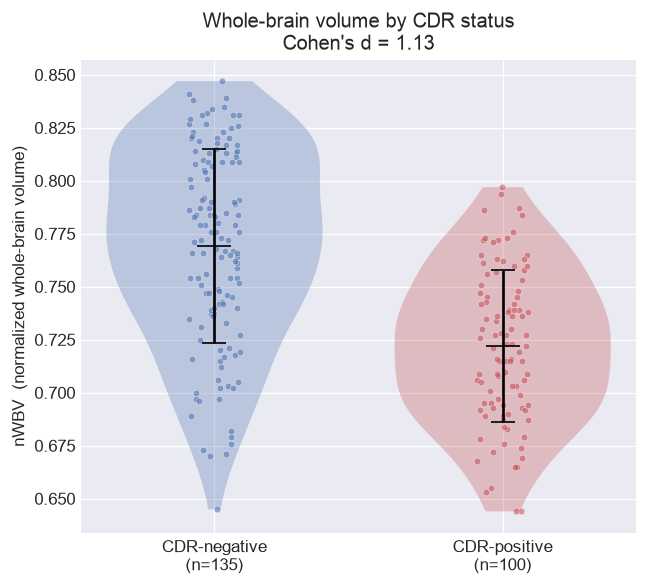

In [4]:
neg = df.loc[~df['CDR_positive'], 'nWBV'].to_numpy()
pos = df.loc[df['CDR_positive'], 'nWBV'].to_numpy()

# Cohen's d: the difference in means expressed in pooled standard deviations, so it is
# comparable across variables measured on different scales.
pooled_sd = np.sqrt(((len(neg) - 1) * neg.var(ddof=1) + (len(pos) - 1) * pos.var(ddof=1))
                    / (len(neg) + len(pos) - 2))
cohens_d = (neg.mean() - pos.mean()) / pooled_sd

fig, ax = plt.subplots(figsize=(5.5, 5))

parts = ax.violinplot([neg, pos], positions=[1, 2], widths=0.75, showextrema=False)
for body, colour in zip(parts['bodies'], [NEG_COLOR, POS_COLOR]):
    body.set_facecolor(colour)
    body.set_alpha(0.30)

rng = np.random.default_rng(0)   # fixed seed so the jitter is the same every run
for x, values, colour in [(1, neg, NEG_COLOR), (2, pos, POS_COLOR)]:
    jitter = rng.uniform(-0.09, 0.09, size=len(values))
    ax.scatter(x + jitter, values, s=16, color=colour, alpha=0.55,
               edgecolor='white', linewidth=0.4, zorder=3)
    ax.errorbar(x, values.mean(), yerr=values.std(ddof=1), fmt='_', color='black',
                markersize=20, capsize=7, elinewidth=1.6, zorder=4)

ax.set_xticks([1, 2])
ax.set_xticklabels([f'{NEG_LABEL}\n(n={len(neg)})', f'{POS_LABEL}\n(n={len(pos)})'])
ax.set_ylabel('nWBV  (normalized whole-brain volume)')
ax.set_title(f"Whole-brain volume by CDR status\nCohen's d = {cohens_d:.2f}")
fig.tight_layout()
plt.show()

## Why age has to be dealt with

nWBV falls with **normal** ageing, and the CDR-positive group is older. So some of the
separation in the plot above is not impairment at all — it is age. The trend lines below
make the slope visible within each group; the shaded band is the narrow age window used in
analysis (3), where age is held roughly fixed.

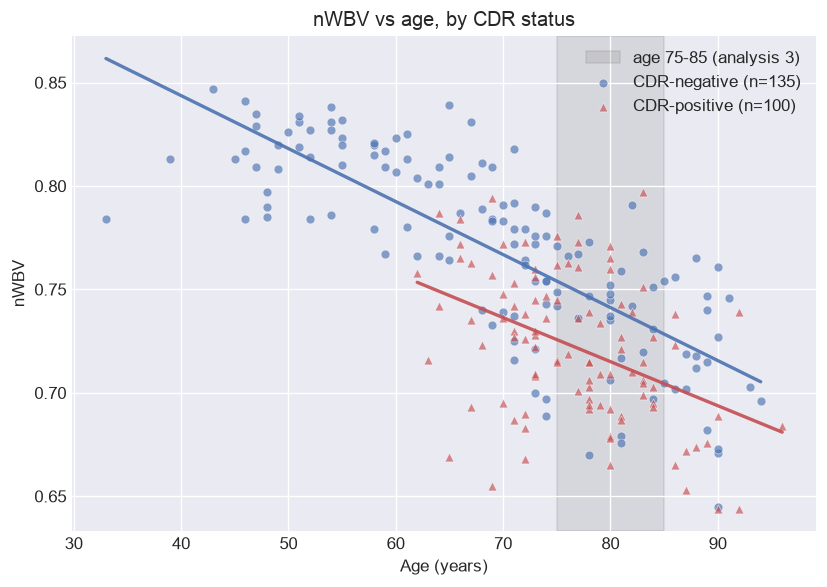

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.axvspan(75, 85, color='0.4', alpha=0.15, zorder=0, label='age 75-85 (analysis 3)')

for mask, colour, marker, label in [
    (~df['CDR_positive'], NEG_COLOR, 'o', NEG_LABEL),
    (df['CDR_positive'], POS_COLOR, '^', POS_LABEL),
]:
    sub = df[mask]
    ax.scatter(sub['Age'], sub['nWBV'], s=28, marker=marker, color=colour, alpha=0.65,
               edgecolor='white', linewidth=0.4, label=f'{label} (n={len(sub)})')
    # Least-squares trend line per group -- the downward slope IS the age confound.
    slope, intercept = np.polyfit(sub['Age'], sub['nWBV'], 1)
    xs = np.linspace(sub['Age'].min(), sub['Age'].max(), 50)
    ax.plot(xs, slope * xs + intercept, color=colour, linewidth=2, alpha=0.9)

ax.set_xlabel('Age (years)')
ax.set_ylabel('nWBV')
ax.set_title('nWBV vs age, by CDR status')
ax.legend(loc='upper right', framealpha=0.9)
fig.tight_layout()
plt.show()

## Predictive value: one continuous variable, one yes/no outcome

**Logistic regression is the right model; AUC is the right headline number.** They answer
different questions, so we report both.

**AUC** (area under the ROC curve) has a plain-English meaning: *the probability that a
randomly chosen CDR-positive subject has less brain volume than a randomly chosen
CDR-negative one.* Literally, how often does this variable rank the two correctly? 0.5 is
a coin flip, 1.0 is perfect. Two properties make it the right choice here:

- It is **threshold-free** — no arbitrary cutoff to choose.
- It is **prevalence-independent** — it does not change when the mix of classes changes.
  That matters below, because the 75–85 subgroup has a very different mix from the whole
  dataset.

**Accuracy is reported too, but never on its own.** Accuracy is the number everyone
reaches for, and it is the easiest to be fooled by: it depends on the class mix. So every
row also prints `baseline_acc`, the score of a model that ignores the data entirely and
always answers whichever class is commoner. **An accuracy near its baseline means nothing
was learned.** Watch analysis (3), where the baseline is high.

**Balanced accuracy** (the average of sensitivity and specificity) is immune to that trick
— the always-answer-one-class model scores exactly 0.5 — and it is the metric step5 reports
for the CNN, so it is what makes the comparison fair.

A subtlety worth knowing: with a **single** predictor, logistic regression cannot change
the AUC. The logistic curve is monotonic, so it preserves the ordering of subjects, and
AUC only depends on that ordering. The AUC below is a property of the data, not of any
model. Logistic regression earns its place for the interpretable effect size (an odds
ratio per standard deviation), not for the discrimination number.

In [6]:
def evaluate(x, y, name, higher_means_positive):
    """Predictive value of ONE continuous variable x for the binary outcome y.

    higher_means_positive says which direction counts as evidence FOR the positive
    class: True for age (older -> more likely CDR-positive), False for nWBV (less
    brain volume -> more likely CDR-positive). Getting this backwards silently returns
    1 - AUC, which looks like a useless variable rather than a coding mistake.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=bool)
    score = x if higher_means_positive else -x

    auc = roc_auc_score(y, score)

    # Standardize the predictor so the coefficient reads as 'per 1 SD' and is comparable
    # between variables on completely different scales (years vs a 0-1 volume ratio).
    z = ((x - x.mean()) / x.std(ddof=1)).reshape(-1, 1)
    lr = LogisticRegression().fit(z, y)
    odds_ratio_per_sd = float(np.exp(lr.coef_[0, 0]))

    # Sweep every threshold the data actually produces and keep the one with the best
    # balanced accuracy; report the other metrics at that same operating point.
    p = lr.predict_proba(z)[:, 1]
    best = (-1.0, np.nan, np.nan, np.nan)
    for t in np.unique(p):
        pred = p >= t
        sens = (pred & y).sum() / y.sum()
        spec = ((~pred) & (~y)).sum() / (~y).sum()
        bal = (sens + spec) / 2
        if bal > best[0]:
            best = (bal, sens, spec, (pred == y).mean())
    bal_acc, sens, spec, acc = best

    prevalence = y.mean()
    return {
        'analysis': name,
        'n': len(y),
        'prevalence': prevalence,
        'AUC': auc,
        'OR_per_SD': odds_ratio_per_sd,
        'accuracy': acc,
        'baseline_acc': max(prevalence, 1 - prevalence),
        'balanced_acc': bal_acc,
        'sensitivity': sens,
        'specificity': spec,
    }


in_band = df['Age'].between(75, 85)

results = pd.DataFrame([
    evaluate(df['Age'], df['CDR_positive'], '1. Age, all ages', higher_means_positive=True),
    evaluate(df['nWBV'], df['CDR_positive'], '2. nWBV, all ages', higher_means_positive=False),
    evaluate(df.loc[in_band, 'nWBV'], df.loc[in_band, 'CDR_positive'],
             '3. nWBV, age 75-85', higher_means_positive=False),
]).set_index('analysis')

results.round(3)

,n,prevalence,AUC,OR_per_SD,accuracy,baseline_acc,balanced_acc,sensitivity,specificity
analysis,,,,,,,,,
"1. Age, all ages",235,0.426,0.660,2.053,0.626,0.574,0.668,0.950,0.385
"2. nWBV, all ages",235,0.426,0.787,0.304,0.711,0.574,0.731,0.870,0.593
"3. nWBV, age 75-85",76,0.632,0.645,0.639,0.671,0.632,0.680,0.646,0.714


### Reading the table

- **`OR_per_SD` for nWBV will be below 1**, because more brain volume means *lower* odds of
  being CDR-positive. Read `0.3` as "each extra SD of brain volume cuts the odds to 30%".
- **Compare `accuracy` against `baseline_acc` in every row**, especially analysis (3).
- **Compare row 2 against row 3.** Row 2 is nWBV helped along by age; row 3 has that help
  removed. The drop between them is the size of the age confound — but do not read it as
  real until you have seen the confidence intervals in the next cell, because row 3 rests
  on far fewer subjects.

## Bootstrap confidence intervals

A single AUC is a point estimate from one sample of people; resample those people and it
moves. The **bootstrap** estimates how much: draw a new dataset of the same size by
sampling subjects *with replacement*, recompute the AUC, and repeat a few thousand times.
The middle 95% of those values is the confidence interval.

This is not optional decoration here. Analysis (3) uses a much smaller group, so its
interval will be visibly wider — and if the intervals for (2) and (3) overlap heavily,
the apparent difference between them is not evidence of anything.

                      n    AUC  CI_low  CI_high  CI_width
analysis                                                 
1. Age, all ages    235  0.660   0.590    0.732     0.142
2. nWBV, all ages   235  0.787   0.728    0.846     0.118
3. nWBV, age 75-85   76  0.645   0.507    0.779     0.273


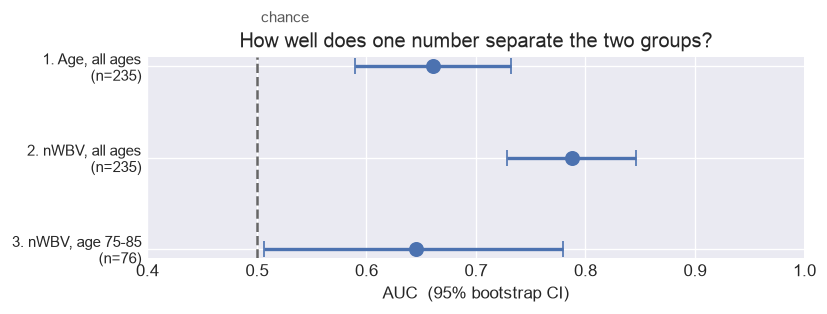

In [7]:
def bootstrap_auc(x, y, higher_means_positive, n_boot=2000, seed=0):
    """Percentile bootstrap CI for the AUC. Returns (point, lo, hi, all_draws)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=bool)
    score = x if higher_means_positive else -x

    rng = np.random.default_rng(seed)
    draws = []
    for _ in range(n_boot):
        idx = rng.integers(0, len(y), len(y))
        # A resample can occasionally contain only one class; AUC is undefined then.
        if y[idx].all() or not y[idx].any():
            continue
        draws.append(roc_auc_score(y[idx], score[idx]))

    draws = np.array(draws)
    return (roc_auc_score(y, score),
            np.percentile(draws, 2.5), np.percentile(draws, 97.5), draws)


specs = [
    ('1. Age, all ages', df['Age'], df['CDR_positive'], True),
    ('2. nWBV, all ages', df['nWBV'], df['CDR_positive'], False),
    ('3. nWBV, age 75-85', df.loc[in_band, 'nWBV'], df.loc[in_band, 'CDR_positive'], False),
]

ci_rows = []
for name, x, y, direction in specs:
    point, lo, hi, _ = bootstrap_auc(x, y, direction)
    ci_rows.append({'analysis': name, 'n': len(y), 'AUC': point,
                    'CI_low': lo, 'CI_high': hi, 'CI_width': hi - lo})

ci = pd.DataFrame(ci_rows).set_index('analysis')
print(ci.round(3))

fig, ax = plt.subplots(figsize=(7, 2.8))
ypos = np.arange(len(ci))[::-1]
ax.errorbar(ci['AUC'], ypos,
            xerr=[ci['AUC'] - ci['CI_low'], ci['CI_high'] - ci['AUC']],
            fmt='o', color='#4C72B0', capsize=5, markersize=8, elinewidth=2)
ax.axvline(0.5, color='0.4', linestyle='--', linewidth=1.5)
ax.text(0.5, ypos.max() + 0.45, ' chance', va='bottom', ha='left', color='0.35', fontsize=9)
ax.set_yticks(ypos)
ax.set_yticklabels([f'{i}\n(n={n})' for i, n in zip(ci.index, ci['n'])], fontsize=9)
ax.set_xlabel('AUC  (95% bootstrap CI)')
ax.set_xlim(0.4, 1.0)
ax.set_title('How well does one number separate the two groups?')
fig.tight_layout()
plt.show()

## What we found

*Fill this in after running the notebook — the numbers above are the evidence, and this
cell is where you commit to what they mean. Four questions worth answering:*

**1. How much of this is just age?** Analysis (1) is the answer. Whatever AUC age alone
achieves is a floor that any "real" predictor has to beat, and it is the same confound
that made the CNN's numbers fall when the cohort was age-matched (`notes/lab-notes.md`
Run 7, `introduction.md` §10).

**2. Does nWBV survive age-matching?** Compare (2) with (3), *and their intervals*. If the
intervals overlap heavily, the honest statement is "we cannot tell from this sample" — not
"nWBV got worse".

**3. Did accuracy mislead you anywhere?** Check each `accuracy` against its
`baseline_acc`. If a row scores near its baseline, the model there is close to worthless
however respectable the accuracy looks.

**4. Is the CNN earning its keep?** The CNN's best honest result is around 0.72 balanced
accuracy (`notes/lab-notes.md` Run 9). Compare it against analysis (2)'s balanced accuracy.
Two caveats before drawing a conclusion:

- **Not like-for-like.** nWBV summarises the *whole brain* and comes from FreeSurfer's
  segmentation — a substantial piece of image processing. The CNN sees one 2-D slice
  through the hippocampus. It is a fair benchmark question, not a fair fight.
- **Different subject sets.** This notebook uses every labelled subject; the CNN uses a
  balanced cohort inside a restricted age band. The numbers are indicative, not exact.

Whatever the result, state it in terms of **CDR status** — this predicts a clinician's
rating of impairment, not Alzheimer's disease (`introduction.md` §1).